# Εργαστήριο 6 — Δέντρα Απόφασης (Decision Trees)

**Μάθημα:** Ευφυή Συστήματα και Συστήματα Υποστήριξης Αποφάσεων  
**Πανεπιστήμιο Δυτικής Αττικής (ΠΑΔΑ)**

---

## Στόχοι Εργαστηρίου

Σε αυτό το εργαστήριο θα:
- Φορτώσουμε και εξερευνήσουμε ένα πραγματικό dataset (Telco Customer Churn)
- Προεπεξεργαστούμε τα δεδομένα για χρήση σε αλγόριθμο μηχανικής μάθησης
- Εκπαιδεύσουμε ένα **Δέντρο Απόφασης (Decision Tree)**
- Οπτικοποιήσουμε το δέντρο και τα αποτελέσματα αξιολόγησης
- Ερμηνεύσουμε τη **σπουδαιότητα χαρακτηριστικών (Feature Importance)**

---
## Εισαγωγή στη Βιβλιοθήκη scikit-learn

### Τι είναι η scikit-learn;

Η **scikit-learn** (`sklearn`) είναι η πιο διαδεδομένη βιβλιοθήκη Μηχανικής Μάθησης για Python. Παρέχει εκατοντάδες έτοιμους αλγόριθμους για ταξινόμηση, παλινδρόμηση, clustering, προεπεξεργασία και αξιολόγηση μοντέλων — όλα με ομοιόμορφο, απλό API.

---

### Αρχιτεκτονική της sklearn

```
scikit-learn
├── sklearn.tree          → Δέντρα Απόφασης (DecisionTreeClassifier, plot_tree)
├── sklearn.ensemble      → Random Forest, Gradient Boosting
├── sklearn.svm           → Support Vector Machines
├── sklearn.neighbors     → k-Nearest Neighbors
├── sklearn.linear_model  → Logistic/Linear Regression
├── sklearn.cluster       → K-Means, DBSCAN
│
├── sklearn.model_selection → train_test_split, cross_val_score, GridSearchCV
├── sklearn.metrics         → accuracy_score, classification_report, ConfusionMatrix
├── sklearn.preprocessing   → LabelEncoder, StandardScaler, OneHotEncoder
└── sklearn.pipeline        → Pipeline (αλυσίδα βημάτων)
```

---

### Το «κοινό API» της sklearn — fit / predict / score

Κάθε αλγόριθμος στη sklearn ακολουθεί το ίδιο μοτίβο, ανεξάρτητα αν είναι δέντρο, SVM ή k-means:

```python
# 1. Δημιουργία μοντέλου με παραμέτρους
model = DecisionTreeClassifier(max_depth=4, criterion='gini')

# 2. Εκπαίδευση (fitting) — το μοντέλο «μαθαίνει» από τα δεδομένα
model.fit(X_train, y_train)

# 3. Πρόβλεψη σε νέα δεδομένα
y_pred = model.predict(X_test)

# 4. Αξιολόγηση — επιστρέφει accuracy
score = model.score(X_test, y_test)
```

> **Γιατί είναι σημαντικό αυτό;** Γιατί αφού μάθετε το API με ένα αλγόριθμο (π.χ. Decision Tree), μπορείτε να αλλάξετε σε οποιονδήποτε άλλο (Random Forest, SVM κ.ά.) αλλάζοντας **μόνο** την πρώτη γραμμή.

---

### Τι θα χρησιμοποιήσουμε σε αυτό το εργαστήριο

| Module | Κλάση / Συνάρτηση | Σκοπός |
|---|---|---|
| `sklearn.tree` | `DecisionTreeClassifier` | Εκπαίδευση δέντρου απόφασης (CART) |
| `sklearn.tree` | `plot_tree` | Οπτικοποίηση δέντρου ως γράφημα |
| `sklearn.tree` | `export_text` | Εκτύπωση δέντρου σε κειμενική μορφή |
| `sklearn.model_selection` | `train_test_split` | Διαχωρισμός dataset σε train/test |
| `sklearn.metrics` | `classification_report` | Precision, Recall, F1 ανά κλάση |
| `sklearn.metrics` | `ConfusionMatrixDisplay` | Οπτικοποίηση πίνακα σύγχυσης |
| `sklearn.preprocessing` | `LabelEncoder` | Μετατροπή κατηγορικών τιμών σε αριθμούς |

---

### Παράμετροι του DecisionTreeClassifier που θα δούμε

| Παράμετρος | Τιμές | Επίδραση |
|---|---|---|
| `criterion` | `'gini'` (CART) ή `'entropy'` (ID3) | Κριτήριο επιλογής διαχωρισμού |
| `max_depth` | ακέραιος ή `None` | Μέγιστο βάθος — ελέγχει Overfitting |
| `min_samples_leaf` | ακέραιος | Ελάχιστα δείγματα σε κάθε φύλλο |
| `random_state` | ακέραιος | Αναπαραγωγιμότητα αποτελεσμάτων |

## 1. Απαιτούμενες Βιβλιοθήκες

| Βιβλιοθήκη | Χρήση |
|---|---|
| `pandas` | Φόρτωση και επεξεργασία δεδομένων (DataFrame) |
| `numpy` | Αριθμητικές πράξεις |
| `matplotlib` | Βασική οπτικοποίηση |
| `seaborn` | Στατιστικά γραφήματα (heatmap, barplot) |
| `sklearn.tree` | `DecisionTreeClassifier`, `plot_tree` |
| `sklearn.model_selection` | `train_test_split` |
| `sklearn.metrics` | `classification_report`, `ConfusionMatrixDisplay` |
| `sklearn.preprocessing` | `LabelEncoder` |

Εγκατάσταση (αν χρειαστεί):
```
pip install pandas numpy matplotlib seaborn scikit-learn
```

In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 9.9 MB/s  0:00:0010.4 MB/s eta 0:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [scikit-learn]━━━━━ 2/3 [scikit-learn]

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    ConfusionMatrixDisplay,
    accuracy_score,
)
from sklearn.preprocessing import LabelEncoder

# Ρύθμιση εμφάνισης
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 110
pd.set_option('display.max_columns', 30)

print('✓ Όλες οι βιβλιοθήκες φορτώθηκαν επιτυχώς.')

✓ Όλες οι βιβλιοθήκες φορτώθηκαν επιτυχώς.


---
## 2. Φόρτωση Dataset — Telco Customer Churn

Χρησιμοποιούμε το δημόσιο dataset **IBM Telco Customer Churn**.  
Περιέχει 7.043 πελάτες τηλεπικοινωνιακής εταιρείας με χαρακτηριστικά όπως:
- `tenure`: πόσους μήνες είναι πελάτης
- `MonthlyCharges`: μηνιαία χρέωση (€)
- `Contract`: τύπος συμβολαίου (Month-to-month / One year / Two year)
- `Churn`: **Στόχος** — αν ακύρωσε (Yes) ή όχι (No)

In [3]:
URL = (
    'https://raw.githubusercontent.com/IBM/'
    'telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv'
)

df = pd.read_csv(URL)
print(f'Γραμμές: {df.shape[0]:,}   Στήλες: {df.shape[1]}')
df.head()

Γραμμές: 7,043   Στήλες: 21


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


---
## 3. Εξερεύνηση Δεδομένων (EDA)

In [38]:
# Τύποι δεδομένων και missing values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

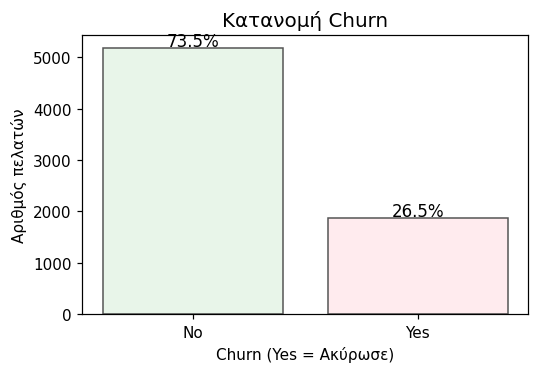

Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [4]:
# Κατανομή της μεταβλητής-στόχου (Churn)
counts = df['Churn'].value_counts()
pct    = df['Churn'].value_counts(normalize=True) * 100

fig, ax = plt.subplots(figsize=(5, 3.5))
bars = ax.bar(counts.index, counts.values,
              color=['#E8F5E9', '#FFEBEE'], edgecolor='#555')
for bar, p in zip(bars, pct.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 40,
            f'{p:.1f}%', ha='center', fontsize=11)
ax.set_title('Κατανομή Churn', fontsize=13)
ax.set_ylabel('Αριθμός πελατών')
ax.set_xlabel('Churn (Yes = Ακύρωσε)')
plt.tight_layout()
plt.show()

print(counts)

In [5]:
# Στατιστικά αριθμητικών χαρακτηριστικών
df[['tenure', 'MonthlyCharges', 'TotalCharges']].describe().round(2)


,tenure,MonthlyCharges
count,7043.00,7043.00
mean,32.37,64.76
std,24.56,30.09
min,0.00,18.25
25%,9.00,35.50
50%,29.00,70.35
75%,55.00,89.85
max,72.00,118.75


---
## 4. Προεπεξεργασία (Preprocessing)

In [6]:
# TotalCharges διαβάστηκε ως string — μετατροπή σε αριθμό
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Αφαίρεση γραμμών με missing values (μόνο 11 γραμμές)
df.dropna(inplace=True)

# Αφαίρεση μη-χρήσιμης στήλης customerID
df.drop(columns=['customerID'], inplace=True)

print(f'Εγγραφές μετά τον καθαρισμό: {len(df):,}')

Εγγραφές μετά τον καθαρισμό: 7,032


### Κωδικοποίηση κατηγορικών μεταβλητών — `LabelEncoder`

Οι αλγόριθμοι Μηχανικής Μάθησης δουλεύουν **μόνο με αριθμούς**. Οι κατηγορικές στήλες (π.χ. `Contract`, `InternetService`, `Churn`) περιέχουν strings και πρέπει να μετατραπούν.

Ο `LabelEncoder` αντιστοιχεί κάθε μοναδική τιμή σε έναν ακέραιο, με **αλφαβητική σειρά**:

| Αρχική τιμή | Κωδικός |
|---|---|
| `"No"` | `0` |
| `"Yes"` | `1` |

---

#### Τι σημαίνει «φυσική σειρά» και γιατί έχει σημασία;

Ο `LabelEncoder` δίνει κωδικούς 0, 1, 2... και το μοντέλο **μπορεί να ερμηνεύσει** ότι 2 > 1 > 0, δηλαδή ότι οι κατηγορίες έχουν **μέγεθος ή σειρά**.

- **Ordinal** (έχουν σειρά) → `LabelEncoder` είναι κατάλληλος
- **Nominal** (δεν έχουν σειρά) → `LabelEncoder` εισάγει ψευδή σχέση

Στο παράδειγμά μας, **όλες** οι κατηγορικές μεταβλητές κωδικοποιήθηκαν με `LabelEncoder`:

| Στήλη | Τιμές | Τύπος | LabelEncoder ΟΚ; |
|---|---|---|---|
| `Contract` | Month-to-month, One year, Two year | Ordinal | Ναι — υπάρχει φυσική σειρά διάρκειας |
| `TechSupport` | No, Yes | Binary | Ναι — 2 τιμές, δεν υπάρχει πρόβλημα |
| `OnlineSecurity` | No, Yes | Binary | Ναι |
| `PaperlessBilling` | No, Yes | Binary | Ναι |
| `InternetService` | DSL, Fiber optic, No | Nominal | Προβληματικό — δεν υπάρχει σειρά |
| `PaymentMethod` | Bank transfer, Credit card, Electronic check, Mailed check | Nominal | Προβληματικό — δεν υπάρχει σειρά |
| `Churn` (target) | No, Yes | Binary | Ναι |

> **Σημείωση:** Στο συγκεκριμένο παράδειγμα **δεν χρησιμοποιείται `OneHotEncoder`**. Για τις nominal μεταβλητές (`InternetService`, `PaymentMethod`) θα ήταν πιο ορθό, αλλά στην πράξη τα δέντρα απόφασης είναι λιγότερο ευαίσθητα σε αυτό το πρόβλημα σε σχέση με γραμμικά μοντέλα.

In [9]:
# Επιλογή χαρακτηριστικών για το μοντέλο
# Χρησιμοποιούμε το υποσύνολο που αντιστοιχεί στο παράδειγμα των διαφανειών
FEATURES = [
    'tenure',
    'MonthlyCharges',
    'TotalCharges',
    'Contract',
    'InternetService',
    'PaymentMethod',
    'TechSupport',
    'OnlineSecurity',
    'PaperlessBilling',
    'SeniorCitizen',
]
TARGET = 'Churn'

data = df[FEATURES + [TARGET]].copy()

# Κωδικοποίηση κατηγορικών μεταβλητών με LabelEncoder
le = LabelEncoder()
cat_cols = data.select_dtypes(include='object').columns.tolist()

for col in cat_cols:
    data[col] = le.fit_transform(data[col])

print('Κατηγορικές στήλες που κωδικοποιήθηκαν:', cat_cols)
data.head()

Κατηγορικές στήλες που κωδικοποιήθηκαν: ['Contract', 'InternetService', 'PaymentMethod', 'TechSupport', 'OnlineSecurity', 'PaperlessBilling', 'Churn']


/tmp/ipykernel_263175/1604774824.py:21: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = data.select_dtypes(include='object').columns.tolist()


,tenure,MonthlyCharges,TotalCharges,Contract,InternetService,PaymentMethod,TechSupport,OnlineSecurity,PaperlessBilling,SeniorCitizen,Churn
0,1,29.85,29.85,0,0,2,0,0,1,0,0
1,34,56.95,1889.50,1,0,3,0,2,0,0,0
2,2,53.85,108.15,0,0,3,0,2,1,0,1
3,45,42.30,1840.75,1,0,0,2,2,0,0,0
4,2,70.70,151.65,0,1,2,0,0,1,0,1


### Διαχωρισμός σε Train / Test set — `train_test_split`

Για να αξιολογήσουμε αν το μοντέλο **γενικεύει** σε νέα δεδομένα (και όχι απλώς αποστηθίζει τα training), χωρίζουμε το dataset σε δύο τμήματα **πριν** την εκπαίδευση:

| Σύνολο | Χρήση | Ποσοστό |
|---|---|---|
| **Train set** | Εκπαίδευση του μοντέλου | 80% |
| **Test set** | Αξιολόγηση σε αόρατα δεδομένα | 20% |

```python
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
```

**Παράμετροι:**

| Παράμετρος | Τιμή | Σημασία |
|---|---|---|
| `test_size=0.20` | 20% | Το 20% των εγγραφών πάει στο test set |
| `random_state=42` | οποιοσδήποτε αριθμός | Καθορίζει την τυχαία κατανομή — εξασφαλίζει **αναπαραγωγιμότητα** (ίδια αποτελέσματα κάθε φορά) |
| `stratify=y` | η στήλη στόχος | Διατηρεί την **ίδια αναλογία κλάσεων** (Churn/No Churn) στα train και test — σημαντικό σε ανισόρροπα datasets |

**Γιατί χρειάζεται το `stratify`:**  
Αν το dataset έχει π.χ. 73% No Churn / 27% Churn, χωρίς `stratify` η τυχαία κατανομή μπορεί να δώσει test set με 40% Churn — μη αντιπροσωπευτικό. Με `stratify=y` και τα δύο σύνολα έχουν ~73/27.

> **Κανόνας:** Το μοντέλο βλέπει **μόνο** το train set κατά την εκπαίδευση. Το test set χρησιμοποιείται αποκλειστικά για την τελική αξιολόγηση.

In [10]:
# Διαχωρισμός σε X (χαρακτηριστικά) και y (στόχος)
X = data[FEATURES]
y = data[TARGET]   # 0 = No churn, 1 = Churn

# Train / Test split — 80% εκπαίδευση, 20% αξιολόγηση
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f'Training set : {len(X_train):,} εγγραφές')
print(f'Test set     : {len(X_test):,} εγγραφές')

Training set : 5,625 εγγραφές
Test set     : 1,407 εγγραφές


---
## 5. Εκπαίδευση Δέντρου Απόφασης

Χρησιμοποιούμε τον αλγόριθμο **CART** (Classification and Regression Trees) που υλοποιεί η `sklearn`.  
Κριτήριο διαχωρισμού: **Gini Impurity** (όπως αναλύσαμε στις διαφάνειες).  
Ορίζουμε `max_depth=4` για να αποφύγουμε το Overfitting.

In [11]:
dt = DecisionTreeClassifier(
    criterion='gini',   # κριτήριο: Gini Impurity
    max_depth=4,        # μέγιστο βάθος δέντρου (αποφυγή Overfitting)
    min_samples_leaf=20,# ελάχιστα παραδείγματα σε φύλλο
    random_state=42,
)

dt.fit(X_train, y_train)

print(f'Βάθος δέντρου : {dt.get_depth()}')
print(f'Αριθμός φύλλων: {dt.get_n_leaves()}')
print(f'Accuracy (train): {dt.score(X_train, y_train):.3f}')
print(f'Accuracy (test) : {dt.score(X_test,  y_test):.3f}')

Βάθος δέντρου : 4
Αριθμός φύλλων: 16
Accuracy (train): 0.788
Accuracy (test) : 0.772


---
## 6. Οπτικοποίηση Δέντρου

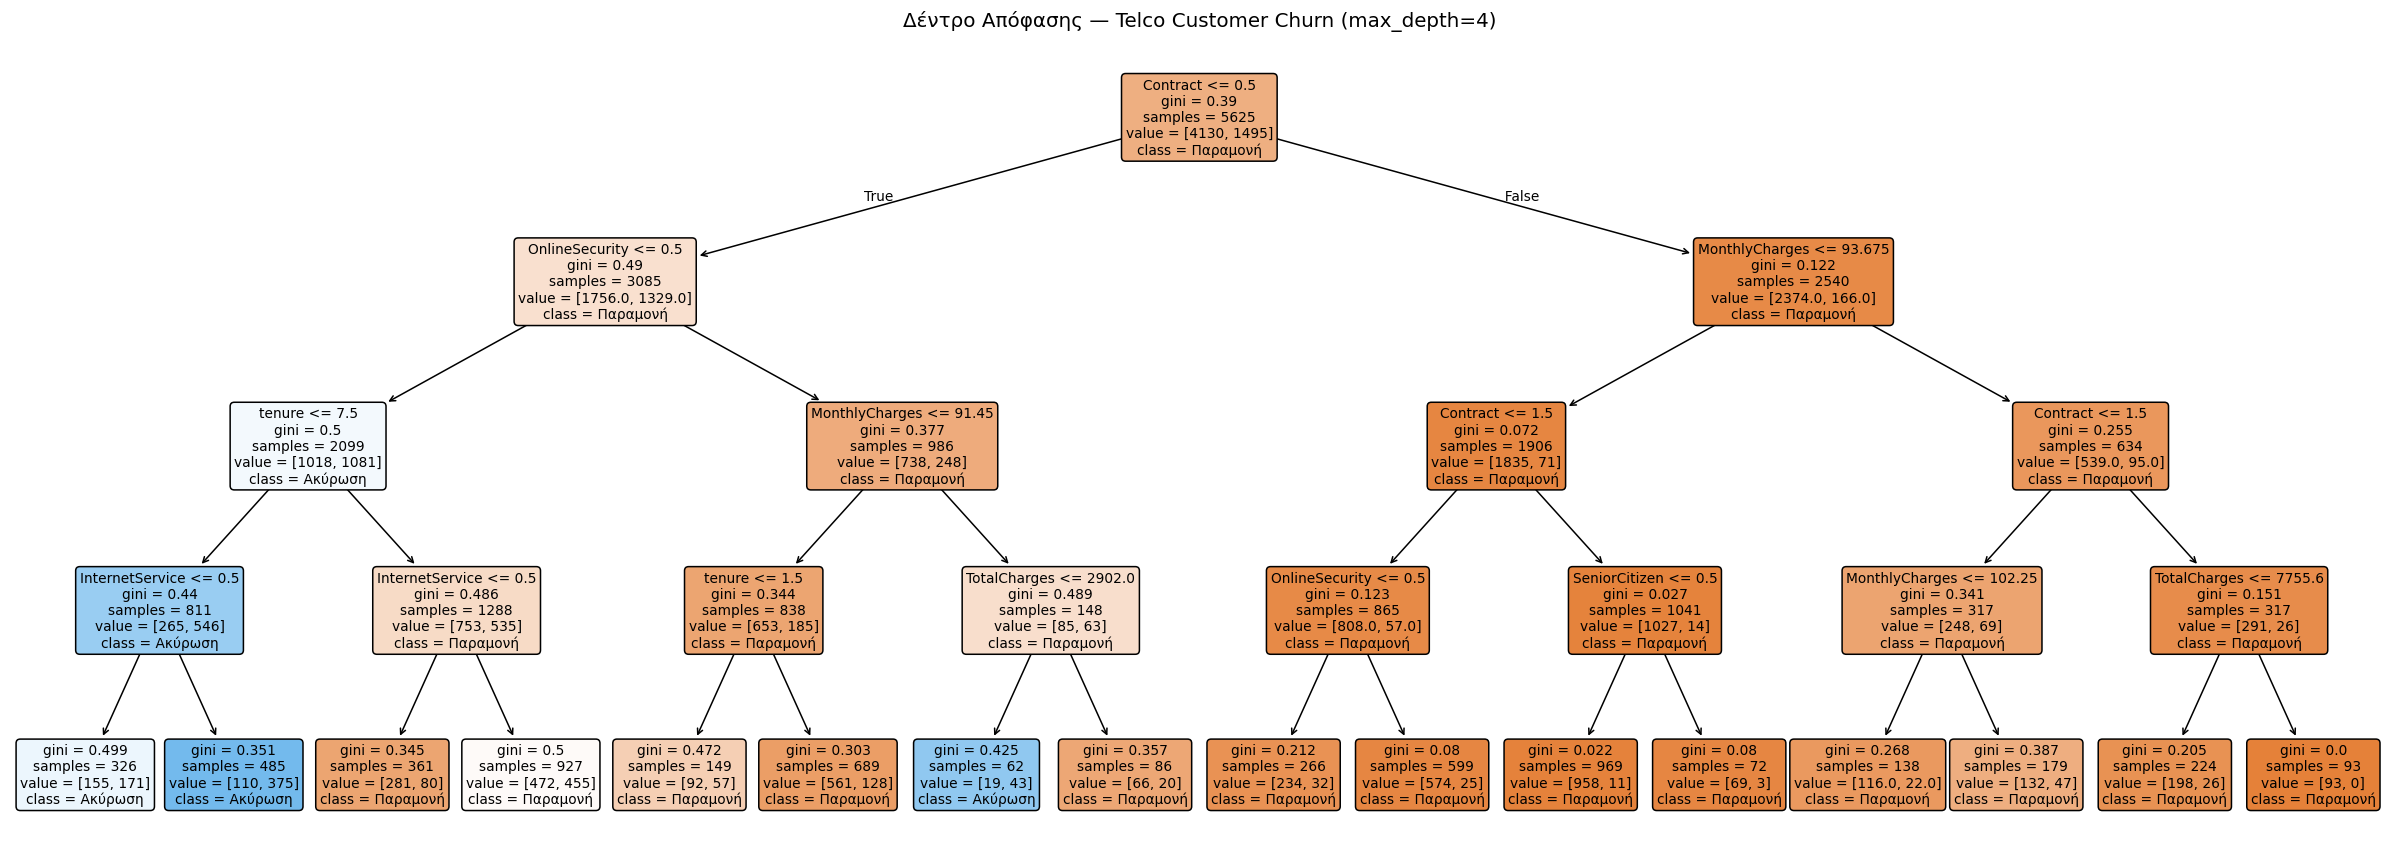

In [12]:
fig, ax = plt.subplots(figsize=(22, 8))
plot_tree(
    dt,
    feature_names=FEATURES,
    class_names=['Παραμονή', 'Ακύρωση'],
    filled=True,
    rounded=True,
    fontsize=9,
    ax=ax,
)
ax.set_title('Δέντρο Απόφασης — Telco Customer Churn (max_depth=4)', fontsize=13)
plt.tight_layout()
plt.show()

### Τι εμφανίζεται σε κάθε κόμβο του δέντρου

Κάθε κόμβος εμφανίζει 4 πληροφορίες:

```
Contract <= 0.5          ← συνθήκη διαχωρισμού (μόνο σε εσωτερικούς κόμβους)
gini = 0.421             ← "ακαθαρσία" του κόμβου
samples = 5634           ← πόσα δείγματα φτάνουν σε αυτόν τον κόμβο
value = [4113, 1521]     ← κατανομή κλάσεων [Παραμονή, Ακύρωση]
class = Παραμονή         ← πλειοψηφούσα κλάση (η πρόβλεψη αν σταματήσουμε εδώ)
```

| Πεδίο | Εξήγηση |
|---|---|
| `gini` | Μετράει πόσο "ανάμεικτες" είναι οι κλάσεις: `0.0` = καθαρός κόμβος, `0.5` = μέγιστη ακαθαρσία (50/50) |
| `samples` | Πόσα δείγματα από το training set πέρασαν από αυτόν τον κόμβο |
| `value` | Πόσα δείγματα ανήκουν σε κάθε κλάση, π.χ. `[4113, 1521]` = 4113 Παραμονή, 1521 Ακύρωση |
| `class` | Η κλάση με τα περισσότερα δείγματα — η τελική πρόβλεψη |

**Διαφορά εσωτερικού κόμβου vs φύλλου:**
- **Εσωτερικός κόμβος:** έχει συνθήκη (`Contract <= 0.5`) → χωρίζει αριστερά/δεξιά
- **Φύλλο:** δεν έχει συνθήκη → είναι η τελική απόφαση του μοντέλου

In [46]:
# Κειμενική αναπαράσταση του δέντρου (εύκολη ανάγνωση)
rules = export_text(dt, feature_names=FEATURES)
print(rules)

|--- Contract <= 0.50
|   |--- OnlineSecurity <= 0.50
|   |   |--- tenure <= 7.50
|   |   |   |--- InternetService <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- InternetService >  0.50
|   |   |   |   |--- class: 1
|   |   |--- tenure >  7.50
|   |   |   |--- InternetService <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- InternetService >  0.50
|   |   |   |   |--- class: 0
|   |--- OnlineSecurity >  0.50
|   |   |--- MonthlyCharges <= 91.45
|   |   |   |--- tenure <= 1.50
|   |   |   |   |--- class: 0
|   |   |   |--- tenure >  1.50
|   |   |   |   |--- class: 0
|   |   |--- MonthlyCharges >  91.45
|   |   |   |--- TotalCharges <= 2902.00
|   |   |   |   |--- class: 1
|   |   |   |--- TotalCharges >  2902.00
|   |   |   |   |--- class: 0
|--- Contract >  0.50
|   |--- MonthlyCharges <= 93.67
|   |   |--- Contract <= 1.50
|   |   |   |--- OnlineSecurity <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- OnlineSecurity >  0.50
|   |   |   |   |--- class: 0
|   |   |

---
## 7. Αξιολόγηση Μοντέλου

### Πρόβλεψη σε νέα δεδομένα — `predict`

Μετά την εκπαίδευση, το μοντέλο μπορεί να προβλέψει την κλάση για κάθε εγγραφή του test set:

```python
y_pred = dt.predict(X_test)
```

Η `predict` παίρνει ως είσοδο έναν πίνακα χαρακτηριστικών `X` και επιστρέφει έναν πίνακα **προβλεπόμενων κλάσεων** — μία τιμή ανά εγγραφή:

```
X_test  →  [εγγραφή_1, εγγραφή_2, εγγραφή_3, ...]
y_pred  →  [0,          1,          0,         ...]
           (Παραμονή)  (Ακύρωση)  (Παραμονή)
```

**Πώς λειτουργεί εσωτερικά στο δέντρο:**  
Κάθε εγγραφή «κατεβαίνει» από τη ρίζα του δέντρου, ακολουθώντας τους κανόνες διαχωρισμού, μέχρι να φτάσει σε φύλλο. Η **πλειοψηφική κλάση** του φύλλου γίνεται η πρόβλεψη.

| | Πραγματική τιμή (`y_test`) | Πρόβλεψη (`y_pred`) |
|---|---|---|
| Σωστή | `0` | `0` |
| Σωστή | `1` | `1` |
| Λάθος | `1` | `0` |
| Λάθος | `0` | `1` |

Η σύγκριση `y_test` vs `y_pred` είναι η βάση για τον **Πίνακα Σύγχυσης** και τις μετρικές αξιολόγησης που ακολουθούν.

> **`predict` vs `predict_proba`:** Η `predict` επιστρέφει απευθείας την κλάση (0 ή 1). Η `predict_proba` επιστρέφει την **πιθανότητα** για κάθε κλάση (π.χ. [0.73, 0.27]) — χρήσιμο όταν θέλουμε να ρυθμίσουμε το κατώφλι απόφασης.

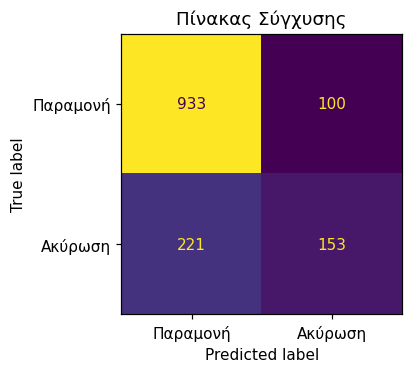

In [14]:
y_pred = dt.predict(X_test)

# Πίνακας Σύγχυσης
fig, ax = plt.subplots(figsize=(4.5, 3.5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['Παραμονή', 'Ακύρωση'],
    colorbar=False,
    ax=ax,
)
ax.set_title('Πίνακας Σύγχυσης', fontsize=12)
plt.tight_layout()
plt.show()

### Ανάλυση Πίνακα Σύγχυσης — TP, TN, FP, FN

Ο πίνακας σύγχυσης χωρίζει τις προβλέψεις σε 4 κατηγορίες. Σε αυτό το πρόβλημα:
- **Positive** = Ακύρωση (Churn = 1) — το γεγονός που θέλουμε να εντοπίσουμε
- **Negative** = Παραμονή (Churn = 0)

| Όρος | Τι έγινε | Επίπτωση |
|---|---|---|
| **TP** (True Positive) | Μοντέλο: Ακύρωση → Πραγματικότητα: Ακύρωση ✅ | Σωστός συναγερμός — στείλαμε προσφορά σε πελάτη που θα έφευγε |
| **TN** (True Negative) | Μοντέλο: Παραμονή → Πραγματικότητα: Παραμονή ✅ | Σωστή ησυχία — δεν ασχοληθήκαμε, και καλά |
| **FP** (False Positive) | Μοντέλο: Ακύρωση → Πραγματικότητα: Παραμονή ❌ | Λάθος συναγερμός — άσκοπη προσφορά σε πελάτη που θα έμενε |
| **FN** (False Negative) | Μοντέλο: Παραμονή → Πραγματικότητα: Ακύρωση ❌ | **Η χασούρα** — χάσαμε πελάτη χωρίς να το ξέρουμε |

> **Σε Churn:** το **FN κοστίζει περισσότερο** από το FP — καλύτερα μία άσκοπη προσφορά παρά ένας χαμένος πελάτης.

In [15]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
TN, FP, FN, TP = cm.ravel()

print("=" * 50)
print(f"  TP (Σωστή Ακύρωση)    : {TP:4d}  ✅")
print(f"  TN (Σωστή Παραμονή)   : {TN:4d}  ✅")
print(f"  FP (Λάθος Συναγερμός) : {FP:4d}  ❌  (έμεινε, είπαμε θα φύγει)")
print(f"  FN (Η Χασούρα)        : {FN:4d}  ❌  (έφυγε, είπαμε θα μείνει)")
print("=" * 50)
total = TP + TN + FP + FN
print(f"\n  Σύνολο test set       : {total}")
print(f"\n  Accuracy  = (TP+TN)/total = ({TP}+{TN})/{total} = {(TP+TN)/total:.3f}")
print(f"  Precision = TP/(TP+FP)   = {TP}/({TP}+{FP}) = {TP/(TP+FP):.3f}")
print(f"  Recall    = TP/(TP+FN)   = {TP}/({TP}+{FN}) = {TP/(TP+FN):.3f}")
print(f"\n  → Το μοντέλο εντοπίζει το {TP/(TP+FN)*100:.0f}% των πελατών που θα ακυρώσουν")
print(f"  → Χάνει το {FN/(TP+FN)*100:.0f}% (FN rate) — αυτοί φεύγουν αθόρυβα")

  TP (Σωστή Ακύρωση)    :  153  ✅
  TN (Σωστή Παραμονή)   :  933  ✅
  FP (Λάθος Συναγερμός) :  100  ❌  (έμεινε, είπαμε θα φύγει)
  FN (Η Χασούρα)        :  221  ❌  (έφυγε, είπαμε θα μείνει)

  Σύνολο test set       : 1407

  Accuracy  = (TP+TN)/total = (153+933)/1407 = 0.772
  Precision = TP/(TP+FP)   = 153/(153+100) = 0.605
  Recall    = TP/(TP+FN)   = 153/(153+221) = 0.409

  → Το μοντέλο εντοπίζει το 41% των πελατών που θα ακυρώσουν
  → Χάνει το 59% (FN rate) — αυτοί φεύγουν αθόρυβα


In [16]:
# Αναφορά ταξινόμησης (Precision, Recall, F1)
print(classification_report(
    y_test, y_pred,
    target_names=['Παραμονή (0)', 'Ακύρωση (1)']
))

              precision    recall  f1-score   support

Παραμονή (0)       0.81      0.90      0.85      1033
 Ακύρωση (1)       0.60      0.41      0.49       374

    accuracy                           0.77      1407
   macro avg       0.71      0.66      0.67      1407
weighted avg       0.75      0.77      0.76      1407



### Ανάλυση Classification Report

```
              precision    recall  f1-score   support

Παραμονή (0)       0.81      0.90      0.85      1033
 Ακύρωση (1)       0.60      0.41      0.49       374

    accuracy                           0.77      1407
   macro avg       0.71      0.66      0.67      1407
weighted avg       0.75      0.77      0.76      1407
```

#### Οι 3 βασικές μετρικές ανά κλάση

| Μετρική | Τύπος | Ερώτηση που απαντά |
|---|---|---|
| **Precision** | TP / (TP + FP) | Από όσους είπα «Ακύρωση», πόσοι όντως ακύρωσαν; |
| **Recall** | TP / (TP + FN) | Από όσους όντως ακύρωσαν, πόσους εντόπισα; |
| **F1-score** | 2 × (P × R) / (P + R) | Αρμονικός μέσος Precision & Recall |
| **Support** | — | Πόσα δείγματα υπάρχουν από αυτή την κλάση στο test set |

#### Ερμηνεία των αποτελεσμάτων

**Παραμονή (0):** Precision=0.81, Recall=0.90  
→ Το μοντέλο είναι καλό στο να αναγνωρίζει τους πελάτες που μένουν — φυσιολογικό, αφού είναι η πλειοψηφία (1033/1407).

**Ακύρωση (1):** Precision=0.60, Recall=0.41  
→ Από όσους προέβλεψε ως churners, το 60% όντως ακύρωσε (αποδεκτό).  
→ Εντόπισε μόνο το 41% των πραγματικών churners — **χάνει το 59%** (υψηλό FN).

#### Macro vs Weighted Average

| | Υπολογισμός | Πότε χρησιμεύει |
|---|---|---|
| **macro avg** | Απλός μέσος όρος κλάσεων (0.71, 0.66, 0.67) | Όταν θέλουμε να μεταχειριστούμε εξίσου κάθε κλάση, ανεξαρτήτως μεγέθους |
| **weighted avg** | Σταθμισμένος με το support (0.75, 0.77, 0.76) | Αντανακλά την πραγματική κατανομή — επηρεάζεται από την πλειοψηφική κλάση |

> Σε ανισόρροπα datasets (όπως εδώ) ο **macro avg** είναι πιο αποκαλυπτικός — δείχνει ότι η απόδοση για την κλάση Ακύρωση (F1=0.49) είναι σημαντικά χαμηλότερη από ό,τι φαίνεται στο weighted avg.

### Το Παράδοξο της Accuracy σε Ανισόρροπα Datasets

Στο dataset μας οι churners είναι **μειοψηφία** (~26%). Ένα «ηλίθιο» μοντέλο που λέει πάντα «Παραμονή» θα έχει υψηλό accuracy — χωρίς να μαθαίνει τίποτα. Ας το δούμε:

In [18]:
import numpy as np

# «Ηλίθιο» baseline: προβλέπει πάντα την πλειοψηφική κλάση (Παραμονή = 0)
y_dummy = np.zeros(len(y_test), dtype=int)

dummy_acc  = accuracy_score(y_test, y_dummy)
model_acc  = accuracy_score(y_test, y_pred)
churn_rate = y_test.mean()

print(f"Κατανομή test set: {(1-churn_rate)*100:.1f}% Παραμονή  /  {churn_rate*100:.1f}% Ακύρωση")
print()
print(f"Accuracy — Dummy (πάντα 'Παραμονή') : {dummy_acc*100:.1f}%  ← φαίνεται καλό...")
print(f"Accuracy — Decision Tree             : {model_acc*100:.1f}%")
print()
print("Πίνακας Σύγχυσης του Dummy μοντέλου:")
cm_dummy = confusion_matrix(y_test, y_dummy)
print(f"  TP={cm_dummy[1,1]}  FN={cm_dummy[1,0]}  ← εντοπίζει ΜΗΔΕΝ churners!")
print(f"  FP={cm_dummy[0,1]}  TN={cm_dummy[0,0]}")
print()
print("→ Το Dummy έχει Recall=0% για churners — είναι άχρηστο.")
print("→ Γι' αυτό κοιτάμε Precision, Recall, F1 — όχι μόνο Accuracy.")

Κατανομή test set: 73.4% Παραμονή  /  26.6% Ακύρωση

Accuracy — Dummy (πάντα 'Παραμονή') : 73.4%  ← φαίνεται καλό...
Accuracy — Decision Tree             : 77.2%

Πίνακας Σύγχυσης του Dummy μοντέλου:
  TP=0  FN=374  ← εντοπίζει ΜΗΔΕΝ churners!
  FP=0  TN=1033

→ Το Dummy έχει Recall=0% για churners — είναι άχρηστο.
→ Γι' αυτό κοιτάμε Precision, Recall, F1 — όχι μόνο Accuracy.


### Threshold — Ρύθμιση Κατωφλίου

Η `predict()` χρησιμοποιεί threshold=0.5 by default. Με `predict_proba()` παίρνουμε την **ακατέργαστη πιθανότητα** και μπορούμε να επιλέξουμε το δικό μας κατώφλι ανάλογα με το business context.

In [22]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Πιθανότητες για κάθε πελάτη (στήλη 1 = P(Ακύρωση))
y_proba = dt.predict_proba(X_test)[:, 1]

print(f"Παράδειγμα — πρώτοι 5 πελάτες:")
for i in range(5):
    print(f"  Πελάτης {i+1}: P(Ακύρωση) = {y_proba[i]:.2f}  →  "
          f"default(t=0.5): {'Ακύρωση' if y_proba[i]>0.5 else 'Παραμονή'}")

print()
print(f"{'Threshold':>10} | {'Precision':>10} | {'Recall':>8} | {'F1':>7} | Σχόλιο")
print("-" * 65)
for t in [0.3, 0.4, 0.5, 0.6, 0.7]:
    y_t = (y_proba >= t).astype(int)
    p = precision_score(y_test, y_t, zero_division=0)
    r = recall_score(y_test, y_t, zero_division=0)
    f = f1_score(y_test, y_t, zero_division=0)
    note = " ← default" if t == 0.5 else ""
    print(f"  t = {t:.1f}   | {p:>9.3f} | {r:>7.3f} | {f:>6.3f} |{note}")

print()
print("Παρατήρηση: καθώς το threshold ↓, Recall ↑ αλλά Precision ↓")

Παράδειγμα — πρώτοι 5 πελάτες:
  Πελάτης 1: P(Ακύρωση) = 0.01  →  default(t=0.5): Παραμονή
  Πελάτης 2: P(Ακύρωση) = 0.77  →  default(t=0.5): Ακύρωση
  Πελάτης 3: P(Ακύρωση) = 0.01  →  default(t=0.5): Παραμονή
  Πελάτης 4: P(Ακύρωση) = 0.19  →  default(t=0.5): Παραμονή
  Πελάτης 5: P(Ακύρωση) = 0.12  →  default(t=0.5): Παραμονή

 Threshold |  Precision |   Recall |      F1 | Σχόλιο
-----------------------------------------------------------------
  t = 0.3   |     0.524 |   0.722 |  0.607 |
  t = 0.4   |     0.539 |   0.679 |  0.601 |
  t = 0.5   |     0.605 |   0.409 |  0.488 | ← default
  t = 0.6   |     0.688 |   0.289 |  0.407 |
  t = 0.7   |     0.694 |   0.267 |  0.386 |

Παρατήρηση: καθώς το threshold ↓, Recall ↑ αλλά Precision ↓


### Καμπύλη ROC & AUC

**ROC** *(Receiver Operating Characteristic)* — απεικονίζει TPR vs FPR για κάθε δυνατό threshold.  
**AUC** *(Area Under the Curve)* — ένας αριθμός 0–1 που συνοψίζει την ποιότητα του μοντέλου ανεξάρτητα από threshold.

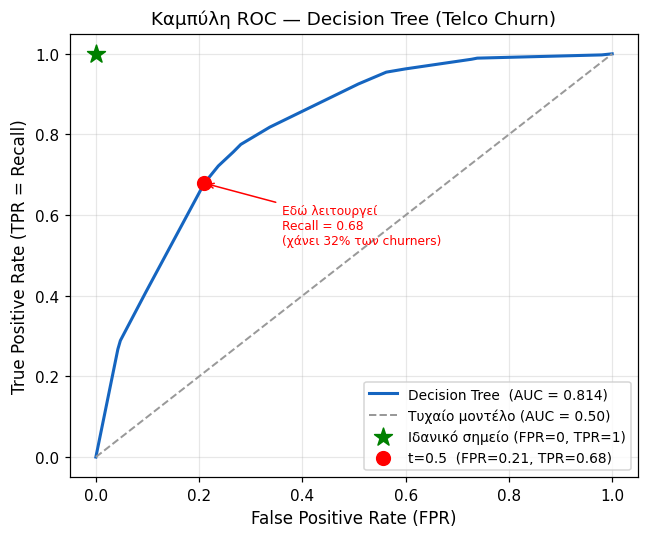

AUC = 0.814  — καλή διαχωριστική ικανότητα (ranking)
Recall (t=0.5) = 0.68  — εντοπίζει μόνο το 68% των churners

→ Το υψηλό AUC δείχνει ότι το μοντέλο ΜΠΟΡΕί να ξεχωρίσει τις κλάσεις,
  αλλά στο default threshold=0.5 το Recall είναι μόλις 41%.
  Για Churn detection χρειαζόμαστε καλύτερο μοντέλο, όχι απλώς ρύθμιση threshold.


In [28]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

fig, ax = plt.subplots(figsize=(6, 5))

# ROC καμπύλη
ax.plot(fpr, tpr, color='#1565C0', lw=2,
        label=f'Decision Tree  (AUC = {auc:.3f})')

# Διαγώνιος τυχαίου ταξινομητή
ax.plot([0, 1], [0, 1], color='#999', lw=1.3, linestyle='--',
        label='Τυχαίο μοντέλο (AUC = 0.50)')

# Ιδανικό σημείο (0, 1)
ax.scatter(0, 1, color='green', zorder=5, s=150, marker='*',
           label='Ιδανικό σημείο (FPR=0, TPR=1)')

# Operating point t=0.5
idx = np.argmin(np.abs(thresholds - 0.5))
ax.scatter(fpr[idx], tpr[idx], color='red', zorder=5, s=80,
           label=f't=0.5  (FPR={fpr[idx]:.2f}, TPR={tpr[idx]:.2f})')
ax.annotate(
    f'Εδώ λειτουργεί\nRecall = {tpr[idx]:.2f}\n(χάνει {1-tpr[idx]:.0%} των churners)',
    xy=(fpr[idx], tpr[idx]),
    xytext=(fpr[idx]+0.15, tpr[idx]-0.15),
    fontsize=8, color='red',
    arrowprops=dict(arrowstyle='->', color='red', lw=1)
)

ax.set_xlabel('False Positive Rate (FPR)', fontsize=11)
ax.set_ylabel('True Positive Rate (TPR = Recall)', fontsize=11)
ax.set_title('Καμπύλη ROC — Decision Tree (Telco Churn)', fontsize=12)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'AUC = {auc:.3f}  — καλή διαχωριστική ικανότητα (ranking)')
print(f'Recall (t=0.5) = {tpr[idx]:.2f}  — εντοπίζει μόνο το {tpr[idx]*100:.0f}% των churners')
print()
print('→ Το υψηλό AUC δείχνει ότι το μοντέλο ΜΠΟΡΕί να ξεχωρίσει τις κλάσεις,')
print('  αλλά στο default threshold=0.5 το Recall είναι μόλις 41%.')
print('  Για Churn detection χρειαζόμαστε καλύτερο μοντέλο, όχι απλώς ρύθμιση threshold.')


---
## 8. Σπουδαιότητα Χαρακτηριστικών (Feature Importance)

Το CART υπολογίζει αυτόματα πόσο κάθε χαρακτηριστικό συνέβαλε στη **μείωση του Gini** σε όλους τους κόμβους.

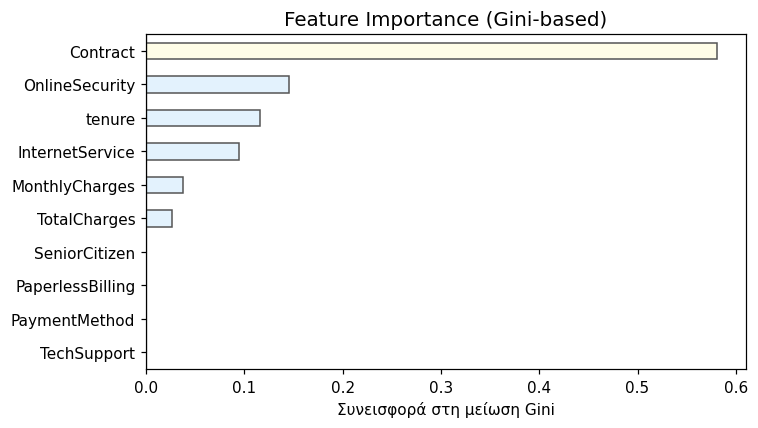

Contract            0.581046
OnlineSecurity      0.145715
tenure              0.115553
InternetService     0.094329
MonthlyCharges      0.037082
TotalCharges        0.026087
SeniorCitizen       0.000188
TechSupport         0.000000
PaymentMethod       0.000000
PaperlessBilling    0.000000


In [53]:
importance = pd.Series(
    dt.feature_importances_, index=FEATURES
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(7, 4))
colors = ['#E3F2FD' if v < importance.max() else '#FFFDE7'
          for v in importance.values]
importance.plot.barh(ax=ax, color=colors, edgecolor='#555')
ax.set_title('Feature Importance (Gini-based)', fontsize=13)
ax.set_xlabel('Συνεισφορά στη μείωση Gini')
ax.axvline(0, color='#555', linewidth=0.8)
plt.tight_layout()
plt.show()

print(importance.sort_values(ascending=False).to_string())

---
## 9. Επίδραση του max_depth στην Ακρίβεια

Παρατηρούμε πώς το βάθος του δέντρου επηρεάζει το **Overfitting**.

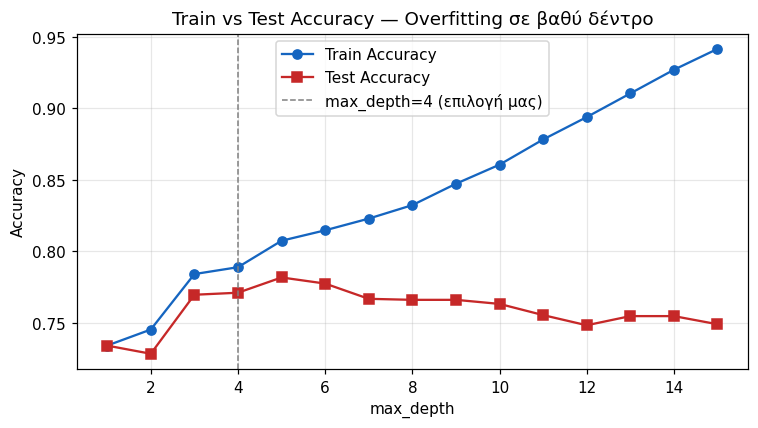

In [54]:
depths = range(1, 16)
train_scores, test_scores = [], []

for d in depths:
    m = DecisionTreeClassifier(criterion='gini', max_depth=d, random_state=42)
    m.fit(X_train, y_train)
    train_scores.append(m.score(X_train, y_train))
    test_scores.append(m.score(X_test, y_test))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(depths, train_scores, 'o-', label='Train Accuracy', color='#1565C0')
ax.plot(depths, test_scores,  's-', label='Test Accuracy',  color='#C62828')
ax.axvline(4, color='gray', linestyle='--', linewidth=1, label='max_depth=4 (επιλογή μας)')
ax.set_xlabel('max_depth')
ax.set_ylabel('Accuracy')
ax.set_title('Train vs Test Accuracy — Overfitting σε βαθύ δέντρο', fontsize=12)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## 10. Ασκήσεις

**Άσκηση 1 — Αλλαγή κριτηρίου:**  
Αλλάξτε το `criterion` από `'gini'` σε `'entropy'` (ID3). Συγκρίνετε:
- Accuracy στο test set
- Feature importance
- Βάθος και αριθμό φύλλων

**Άσκηση 2 — Πλήρες δέντρο χωρίς όριο:**  
Εκπαιδεύστε ένα δέντρο χωρίς `max_depth` (`max_depth=None`).  
Τι παρατηρείτε στο train accuracy vs test accuracy; Πώς ονομάζεται αυτό το φαινόμενο;

**Άσκηση 3 — Gini ανά κόμβο:**  
Στο γράφημα `plot_tree`, κάθε κόμβος εμφανίζει το `gini = X.XX`.  
Βρείτε τον κόμβο ρίζα και τα παιδιά του. Υπολογίστε χειρωνακτικά το **Gini Gain** της πρώτης διάσπασης και επαληθεύστε ότι συμφωνεί με την εξίσωση από τις διαφάνειες.

**Άσκηση 4 — Νέος πελάτης:**  
Χρησιμοποιήστε το εκπαιδευμένο μοντέλο για να προβλέψετε αν ο παρακάτω πελάτης θα ακυρώσει:
```python
# Προσαρμόστε τις τιμές ανάλογα με την κωδικοποίηση (LabelEncoder)
νέος_πελάτης = pd.DataFrame([{
    'tenure': 5,
    'MonthlyCharges': 78.0,
    'TotalCharges': 390.0,
    'Contract': ...,        # τι τιμή αντιστοιχεί στο 'Month-to-month';
    'InternetService': ..., # τι τιμή αντιστοιχεί στο 'Fiber optic';
    # ... (συμπληρώστε τα υπόλοιπα)
}])
dt.predict(νέος_πελάτης)
```